In [47]:
import pandas as pd
import numpy as np

In [48]:
df=pd.read_csv('D:\Download\Data Analyst course/bepec\ML_stat\Auto_price\Automobile price data _Raw.csv')

In [49]:
df.replace('?', pd.NA, inplace=True)

In [ ]:
df=df.dropna()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
10,2,192,bmw,gas,std,two,sedan,rwd,front,101.2,...,108,mpfi,3.5,2.8,8.8,101,5800,23,29,16430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [65]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [67]:
numeric_cols_with_issues = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']

for col in numeric_cols_with_issues:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [73]:
df.dtypes

symboling              int64
normalized-losses      int64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

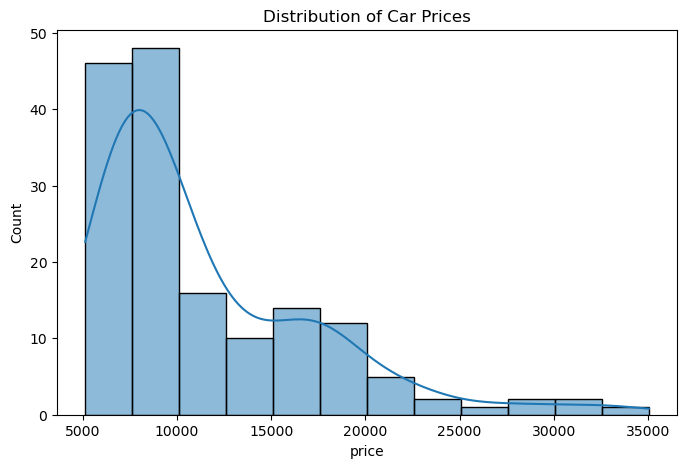

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Car Prices')
plt.show()

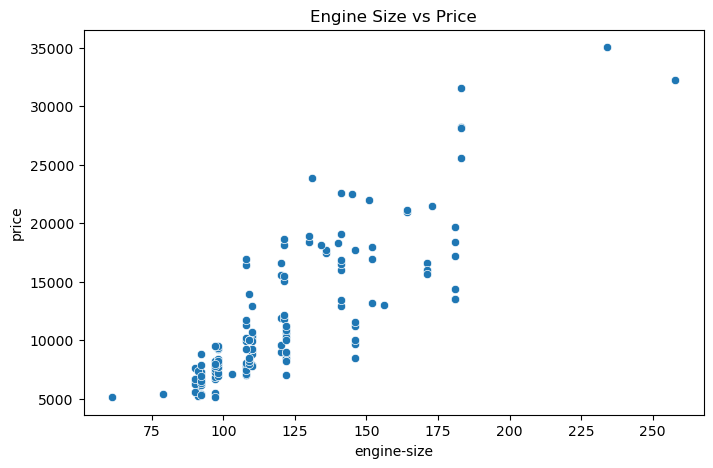

In [75]:
# Scatter plot for Engine Size vs Price
plt.figure(figsize=(8, 5))
sns.scatterplot(x='engine-size', y='price', data=df)
plt.title('Engine Size vs Price')
plt.show()

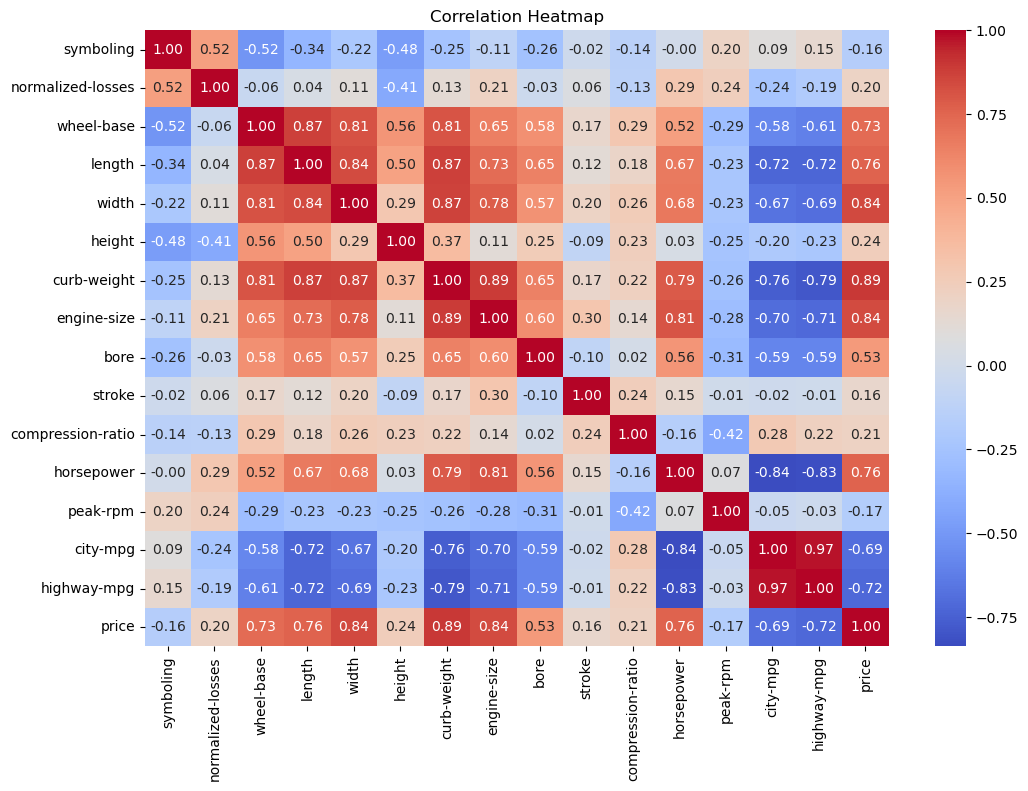

In [76]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [77]:
x=df.iloc[:,:25]

In [78]:
y=df.iloc[:,25:]

In [81]:
cat_col=x.select_dtypes(include=['object']).columns

In [82]:
x_encode=pd.get_dummies(x, columns=cat_col, drop_first=True)

In [83]:
print(f"Original features: {x.shape[1]}")
print(f"Encoded features: {x_encode.shape[1]}")

Original features: 25
Encoded features: 54


In [84]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_encode, y, test_size=0.2, random_state=42)

In [86]:
print(f"Training data size: {x_train.shape[0]} rows")
print(f"Testing data size: {x_test.shape[0]} rows")

Training data size: 127 rows
Testing data size: 32 rows


In [87]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [88]:
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)
lr_preds = lr_model.predict(x_test)

In [89]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(x_train, y_train)
rf_preds = rf_model.predict(x_test)

c:\Users\arunk\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [101]:
rf_train_preds = rf_model.predict(x_train)
lr_train_preds = lr_model.predict(x_train)

In [102]:
print(f"Training R-squared rf: {r2_score(y_train, rf_train_preds):.2f}")
print(f"Training R-squared lr: {r2_score(y_train, lr_train_preds):.2f}")

Training R-squared rf: 0.98
Training R-squared lr: 0.98


In [92]:
print("--- Linear Regression ---")
print(f"R-squared: {r2_score(y_test, lr_preds):.2f}")
print(f"MAE: ${mean_absolute_error(y_test, lr_preds):.2f}")

print("\n--- Random Forest ---")
print(f"R-squared: {r2_score(y_test, rf_preds):.2f}")
print(f"MAE: ${mean_absolute_error(y_test, rf_preds):.2f}")

--- Linear Regression ---
R-squared: 0.81
MAE: $1429.75

--- Random Forest ---
R-squared: 0.84
MAE: $1297.79


In [103]:
from sklearn.model_selection import GridSearchCV

In [104]:
param_grid = {
    'n_estimators': [50, 100, 200],    
    'max_depth': [5, 10, None],         
    'min_samples_split': [2, 5, 10],     
    'min_samples_leaf': [1, 2, 4]
}

In [105]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3, 
    n_jobs=-1, # Uses all your CPU cores to run faster!
    scoring='r2'
)

In [106]:
grid_search.fit(x_train, y_train.values.ravel())

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [107]:
best_rf = grid_search.best_estimator_

In [108]:
tuned_train_preds = best_rf.predict(x_train)
tuned_test_preds = best_rf.predict(x_test)

In [109]:
print(f"Tuned Training R-squared: {r2_score(y_train, tuned_train_preds):.2f}")
print(f"Tuned Testing R-squared: {r2_score(y_test, tuned_test_preds):.2f}")
print(f"Best Parameters: {grid_search.best_params_}")

Tuned Training R-squared: 0.96
Tuned Testing R-squared: 0.82
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}


In [110]:
importances = best_rf.feature_importances_
feature_names = x_train.columns

In [111]:
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

In [112]:
top_10_features = importance_df.sort_values(by='Importance', ascending=False).head(10)

C:\Users\arunk\AppData\Local\Temp\ipykernel_16916\3733632073.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


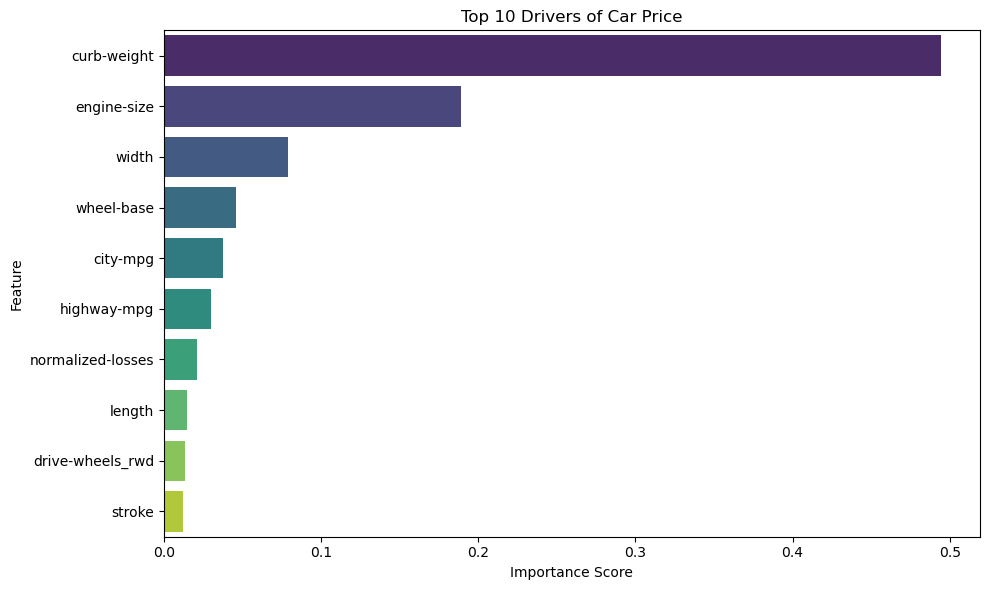

In [113]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
plt.title('Top 10 Drivers of Car Price')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()